# 03 - SQL EDA and Business Analysis

**Goal:** answer business questions with warehouse queries and visualize the same metrics in Python.

Set `USE_MYSQL = True` after Notebook 02 has loaded the warehouse. The local CSV path remains available so EDA can proceed without database credentials.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid", palette="Set2")


def find_project_root() -> Path:
    """Find the project root whether Jupyter starts here or in notebooks/."""
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "datasets").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    raise FileNotFoundError("Start Jupyter from the project root or notebooks directory.")


ROOT = find_project_root()
DATASETS = ROOT / "datasets"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

Project root: C:\Users\HP\Desktop\Customer 360 Intelligence


In [2]:
import getpass
import os
from sqlalchemy import URL, create_engine, text

USE_MYSQL = False
engine = None

if USE_MYSQL:
    mysql_url = URL.create(
        "mysql+pymysql",
        username=os.getenv("MYSQL_USER", "root"),
        password=os.getenv("MYSQL_PASSWORD") or getpass.getpass("MySQL password: "),
        host=os.getenv("MYSQL_HOST", "localhost"),
        port=int(os.getenv("MYSQL_PORT", "3306")),
        database=os.getenv("MYSQL_DATABASE", "customer360"),
    )
    engine = create_engine(mysql_url, pool_pre_ping=True)
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    print("MySQL connection successful.")
else:
    print("Using processed CSV extracts for local EDA.")


def run_sql(query: str) -> pd.DataFrame:
    """Execute a read-only analytical query against the configured warehouse."""
    if engine is None:
        raise RuntimeError("Set USE_MYSQL = True before calling run_sql().")
    return pd.read_sql(text(query), engine)

Using processed CSV extracts for local EDA.


## Load local warehouse extracts for reproducible charts

In [3]:
orders = pd.read_csv(PROCESSED / "fact_orders.csv", parse_dates=["purchase_date"])
customers = pd.read_csv(PROCESSED / "dim_customer.csv")
products = pd.read_csv(PROCESSED / "dim_product.csv")
payments = pd.read_csv(PROCESSED / "fact_payments.csv")
web = pd.read_csv(PROCESSED / "fact_web_activity.csv", parse_dates=["event_time"])
customer_reviews = pd.read_csv(PROCESSED / "fact_customer_reviews.csv")
product_reviews = pd.read_csv(PROCESSED / "fact_product_reviews.csv")
campaigns = pd.read_csv(PROCESSED / "fact_campaign.csv")
campaign_dim = pd.read_csv(PROCESSED / "dim_campaign.csv")

valid_orders = orders.loc[~orders["order_status"].isin(["canceled", "unavailable"])].copy()

## 1. Revenue by state and city

Business use: allocate sales coverage and logistics attention to high-value regions.

,state,revenue,orders,customers
25,SP,5165781.70,41130,39741
18,RJ,1811484.23,12698,12238
10,MG,1573269.18,11493,11128
22,RS,742639.78,5415,5232
17,PR,675928.19,4980,4821
23,SC,518276.28,3600,3498
4,BA,506878.84,3342,3242
6,DF,300085.75,2117,2054
8,GO,288157.45,1997,1932
7,ES,273622.03,2019,1950


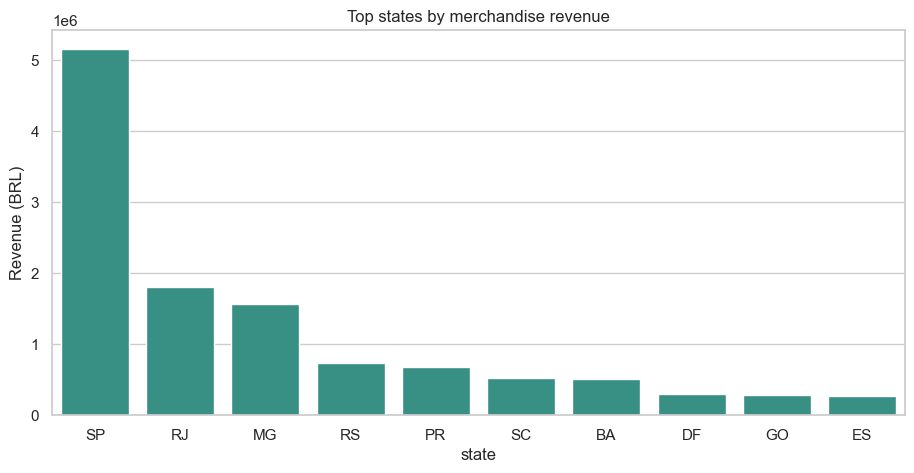

In [4]:
geography = valid_orders.merge(customers, on="customer_id", how="left", validate="many_to_one")
state_sales = (
    geography.groupby("state", as_index=False)
    .agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"), customers=("customer_id", "nunique"))
    .sort_values("revenue", ascending=False)
)
display(state_sales.head(10))
plt.figure(figsize=(11, 5))
sns.barplot(data=state_sales.head(10), x="state", y="revenue", color="#2a9d8f")
plt.title("Top states by merchandise revenue")
plt.ylabel("Revenue (BRL)")
plt.show()

## 2. Monthly revenue trend

,month,revenue,orders,customers
12,2017-10,660179.62,4547,4481
13,2017-11,1003862.14,7421,7313
14,2017-12,742183.79,5618,5551
15,2018-01,945456.29,7187,7088
16,2018-02,837895.43,6624,6468
17,2018-03,981051.06,7168,7077
18,2018-04,993592.98,6919,6863
19,2018-05,992871.75,6833,6775
20,2018-06,863265.53,6145,6106
21,2018-07,878044.27,6233,6172


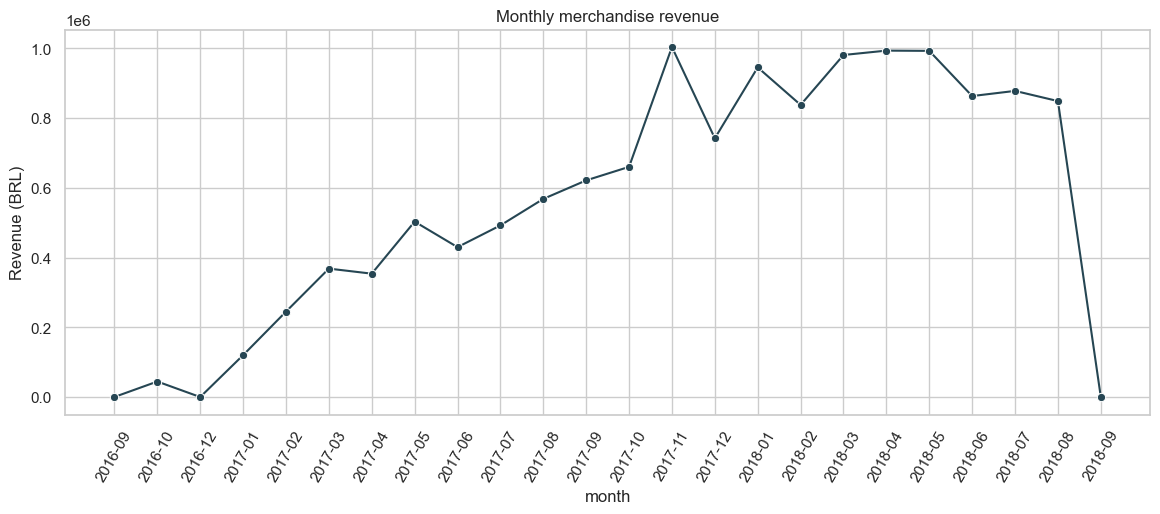

In [5]:
monthly = (
    valid_orders.assign(month=valid_orders["purchase_date"].dt.to_period("M").astype(str))
    .groupby("month", as_index=False)
    .agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"), customers=("customer_id", "nunique"))
)
display(monthly.tail(12))
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly, x="month", y="revenue", marker="o", color="#264653")
plt.xticks(rotation=60)
plt.title("Monthly merchandise revenue")
plt.ylabel("Revenue (BRL)")
plt.show()

## 3. Category repeat-customer rate

A minimum of 30 customers avoids promoting tiny categories with unstable 100% repeat rates.

In [6]:
category_customer = (
    valid_orders.merge(products[["product_id", "category_name_english"]], on="product_id", how="left")
    .groupby(["category_name_english", "customer_id"], as_index=False)
    .agg(order_count=("order_id", "nunique"))
)
category_repeat = (
    category_customer.assign(is_repeat=category_customer["order_count"].gt(1))
    .groupby("category_name_english", as_index=False)
    .agg(customers=("customer_id", "nunique"), repeat_customers=("is_repeat", "sum"))
)
category_repeat["repeat_rate_pct"] = 100 * category_repeat["repeat_customers"] / category_repeat["customers"]
category_repeat = category_repeat.query("customers >= 30").sort_values(
    ["repeat_rate_pct", "customers"], ascending=[False, False]
)
display(category_repeat.head(15))

,category_name_english,customers,repeat_customers,repeat_rate_pct
44,home_appliances,701,52,7.417974
38,furniture_bedroom,91,3,3.296703
28,fashion_bags_accessories,1792,55,3.069196
7,bed_bath_table,9127,252,2.761039
65,sports_leisure,7471,182,2.436086
39,furniture_decor,6294,128,2.033683
15,computers_accessories,6522,126,1.931923
9,books_imported,52,1,1.923077
30,fashion_male_clothing,109,2,1.834862
25,dvds_blu_ray,56,1,1.785714


## 4. Most loyal customers and average basket value

In [7]:
customer_value = (
    valid_orders.groupby("customer_id", as_index=False)
    .agg(total_orders=("order_id", "nunique"), total_spend=("revenue", "sum"), last_purchase=("purchase_date", "max"))
)
customer_value["avg_order_value"] = customer_value["total_spend"] / customer_value["total_orders"]
display(customer_value.query("total_orders > 1").sort_values(["total_orders", "total_spend"], ascending=False).head(20))
print(f"Overall average order value: BRL {valid_orders.groupby('order_id')['revenue'].sum().mean():,.2f}")

,customer_id,total_orders,total_spend,last_purchase,avg_order_value
52352,8d50f5eadf50201ccdcedfb9e2ac8455,16,729.62,2018-08-20 19:14:26,45.601250
23198,3e43e6105506432c953e165fb2acf44c,9,1000.85,2018-02-27 18:36:39,111.205556
10234,1b6c7548a2a1f9037c1fd3ddfed95f33,7,809.21,2018-02-14 13:22:12,115.601429
75205,ca77025e7201e3b30c44b472ff346268,7,806.61,2018-06-01 11:38:29,115.230000
37370,6469f99c1f9dfae7733b25662e7f1782,7,664.20,2018-06-28 00:43:34,94.885714
26733,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,836.60,2018-01-24 15:15:26,139.433333
81925,dc813062e0fc23409cd255f7f53c7074,6,687.76,2018-08-23 00:07:26,114.626667
37161,63cfc61cee11cbe306bff5857d00bfe4,6,579.81,2018-05-28 17:20:02,96.635000
89402,f0e310a6839dce9de1638e0fe5ab282a,6,438.09,2018-04-05 09:04:45,73.015000
7091,12f5d6e1cbf93dafd9dcc19095df0b3d,6,58.40,2017-01-05 15:25:10,9.733333


Overall average order value: BRL 137.42


## 5. Web visitors without a clickstream purchase

In [8]:
web_summary = (
    web.groupby("customer_id", as_index=False)
    .agg(
        sessions=("user_session", "nunique"),
        views=("event_type", lambda values: values.eq("view").sum()),
        cart_additions=("event_type", lambda values: values.eq("cart").sum()),
        purchases=("event_type", lambda values: values.eq("purchase").sum()),
    )
)
visits_no_purchase = web_summary.query("purchases == 0").sort_values("views", ascending=False)
display(visits_no_purchase.head(20))

,customer_id,sessions,views,cart_additions,purchases
31533,ce5d5c57caf43762f3054808fc5f3c60,1481,1744,246,0
35485,e8933aa8c4fbfdec4781ccdf0a39740b,353,356,0,0
4450,1d3e82e030ccc817ea128b644d815a9a,9,262,0,0
15662,663d07f21363a4afd7732461494323c8,5,214,70,0
34036,dec8755381b4ce5dd52a2f90f938f072,198,198,0,0
7916,33d63b8742df3d30c44de39655096da8,5,193,1,0
31153,cbd059178a127dc1fe0171c00e743630,7,188,68,0
33744,dcef1ca220ebeef4cfe6c6fc5ce603e6,4,171,4,0
11293,49e9462601934a7370db9721ac62f9ad,23,159,53,0
8405,3725fd91186d2373de68908692e09f11,3,154,73,0


## 6. Marketing funnel and ROI

These results are demonstrations based on synthetic events. They must not be presented as observed Olist campaign performance.

In [9]:
campaign_summary = (
    campaigns.groupby("campaign_id", as_index=False)
    .agg(
        sent=("email_sent", "sum"), opened=("opened", "sum"), clicked=("clicked", "sum"),
        converted=("converted", "sum"), revenue=("revenue_generated", "sum"),
    )
    .merge(campaign_dim[["campaign_id", "campaign_type", "campaign_cost"]], on="campaign_id", validate="one_to_one")
)
campaign_summary["open_rate"] = campaign_summary["opened"] / campaign_summary["sent"].replace(0, np.nan)
campaign_summary["ctr"] = campaign_summary["clicked"] / campaign_summary["sent"].replace(0, np.nan)
campaign_summary["click_conversion_rate"] = campaign_summary["converted"] / campaign_summary["clicked"].replace(0, np.nan)
campaign_summary["roi"] = (campaign_summary["revenue"] - campaign_summary["campaign_cost"]) / campaign_summary["campaign_cost"]
display(campaign_summary.sort_values("roi", ascending=False))

,campaign_id,sent,opened,clicked,converted,revenue,campaign_type,campaign_cost,open_rate,ctr,click_conversion_rate,roi
0,CAMP_001,7470,4071,1448,321,57928.74,Email,33478.0,0.544980,0.193842,0.221685,0.730352
6,CAMP_007,7474,4117,1416,314,55274.68,Winback,33164.0,0.550843,0.189457,0.221751,0.666707
4,CAMP_005,7507,4111,1426,341,64212.64,Retargeting,66136.0,0.547622,0.189956,0.239130,-0.029082
3,CAMP_004,7449,4078,1461,322,58287.33,Loyalty,66693.0,0.547456,0.196134,0.220397,-0.126035
2,CAMP_003,7508,4130,1440,337,62708.53,Coupon,87184.0,0.550080,0.191795,0.234028,-0.280734
7,CAMP_008,7464,4111,1410,306,55518.29,Seasonal,91249.0,0.550777,0.188907,0.217021,-0.391574
1,CAMP_002,7565,4144,1449,322,57103.53,SMS,98525.0,0.547786,0.191540,0.222222,-0.420416
5,CAMP_006,7563,4173,1455,306,55848.64,Referral,106566.0,0.551765,0.192384,0.210309,-0.475924


## 7. Customer ratings and external product sentiment

In [10]:
rating_distribution = customer_reviews["rating"].value_counts().sort_index().rename_axis("rating").reset_index(name="reviews")
display(rating_distribution)

external_sentiment = (
    product_reviews.groupby("category_name", as_index=False)
    .agg(review_count=("review_key", "count"), avg_rating=("rating", "mean"), avg_sentiment=("sentiment_score", "mean"))
    .query("review_count >= 20")
    .sort_values("avg_sentiment")
)
display(external_sentiment.head(15))

,rating,reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


,category_name,review_count,avg_rating,avg_sentiment
15,kindle store,35,4.500000,0.342857
5,chargers & adapters,73,4.205479,0.602740
10,electronics features,372,4.424731,0.712366
1,amazon devices & accessories,402,4.440299,0.720149
12,fire tablets,11244,4.457044,0.728522
7,computers/tablets & networking,1055,4.479543,0.736967
11,featured brands,636,4.531447,0.765723
20,tablets,1857,4.532041,0.766020
9,electronics,3357,4.571301,0.784480
8,ebook readers,67,4.611940,0.805970


## Scope notes

- **Revenue by age** cannot be answered because no age field exists.
- **Discount behavior** cannot be answered because Olist has price but no undiscounted reference price or discount amount.
- **Support resolution analytics** cannot be answered because no ticket dataset is present.

Documenting unavailable questions is part of a credible analytics project; invented fields would weaken the result.